In [ ]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"
RESULTS_DIR = REPO_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

RAW_DATA_DIR = Path(os.environ.get("BIRDCLEF_DIR", DATA_DIR / "raw"))

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Fixed seed for the train/val/test split. 
MANIFEST_SEED = 42

print(f"REPO_ROOT     = {REPO_ROOT}")
print(f"RAW_DATA_DIR  = {RAW_DATA_DIR}")
print(f"RAW_DATA_DIR exists: {RAW_DATA_DIR.exists()}")

REPO_ROOT     = c:\Users\Batoul Hammoud\Desktop\naco_project
RAW_DATA_DIR  = c:\Users\Batoul Hammoud\Desktop\naco_project\data\raw
RAW_DATA_DIR exists: True


## Stage 1. Data

Pick five species spanning Aves, Insecta, and Amphibia, then build a clip-level manifest with deterministic 70/15/15 splits per species. The clip count caps (200, 100, 50, 30, 15) give us the imbalance pattern the proposal calls for.

In [2]:
from src import data

SPECIES = [
    ("rubthr1", 200),   # Rufous-bellied Thrush (Aves)
    ("banana", 100),    # Bananaquit (Aves)
    ("244024", 50),     # Giant Cicada (Insecta)
    ("22973", 30),      # Whistling Grass Frog (Amphibia)
    ("24279", 15),      # Lesser Snouted Tree Frog (Amphibia)
]
SPLIT_RATIOS = (0.70, 0.15, 0.15)

# Inverse-frequency weights: rare species get higher weight in the fitness function.
_train_counts = {label: max(1, int(count * SPLIT_RATIOS[0])) for label, count in SPECIES}
CLASS_WEIGHTS = {label: 1.0 / cnt for label, cnt in _train_counts.items()}


In [3]:
manifest = data.build_manifest(
    raw_data_dir=RAW_DATA_DIR,
    species_specs=SPECIES,
    split_ratios=SPLIT_RATIOS,
    seed=MANIFEST_SEED,
)
manifest.to_csv(DATA_DIR / "manifest.csv", index=False)
print(f"Wrote {len(manifest)} clip rows to data/manifest.csv")
manifest.head()

Wrote 395 clip rows to data/manifest.csv


,clip_id,primary_label,common_name,class_name,filename,split
0,XC1003072,rubthr1,Rufous-bellied Thrush,Aves,rubthr1/XC1003072.ogg,train
1,iNat1626515,rubthr1,Rufous-bellied Thrush,Aves,rubthr1/iNat1626515.ogg,val
2,XC587128,rubthr1,Rufous-bellied Thrush,Aves,rubthr1/XC587128.ogg,train
3,iNat1209629,rubthr1,Rufous-bellied Thrush,Aves,rubthr1/iNat1209629.ogg,train
4,XC974643,rubthr1,Rufous-bellied Thrush,Aves,rubthr1/XC974643.ogg,test


In [4]:
data.split_counts(manifest)

split,train,val,test
primary_label,,,
22973,21,4,5
24279,10,2,3
244024,35,8,7
banana,70,15,15
rubthr1,140,30,30


## Stage 2. Feature extraction

Each clip gets cut into non-overlapping 5-second windows, and each window summarized by 34 librosa features (13 MFCCs as mean and std, plus spectral centroid, rolloff, flux, and zero-crossing rate as mean and std).


In [5]:
from src import features

FEATURES_PATH = DATA_DIR / "features.pkl"

if FEATURES_PATH.exists():
    print(f"Loading cached features from {FEATURES_PATH}")
    features_df = pd.read_pickle(FEATURES_PATH)
else:
    print("Extracting features (slow)...")
    features_df = features.extract_all(manifest, raw_data_dir=RAW_DATA_DIR)
    features_df.to_pickle(FEATURES_PATH)
    print(f"Wrote {len(features_df)} window rows to {FEATURES_PATH}")

FEATURE_COLS = features.feature_columns()
print(f"{len(features_df)} windows  x  {len(FEATURE_COLS)} features")
features_df.head()

c:\miniconda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extracting features (slow)...


Extracting features: 100%|██████████| 395/395 [02:58<00:00,  2.21it/s]

Wrote 2504 window rows to c:\Users\Batoul Hammoud\Desktop\naco_project\data\features.pkl
2504 windows  x  34 features



c:\Users\Batoul Hammoud\Desktop\naco_project\src\features.py:157: UserWarning: Skipped 26 clips (shorter than 5.0s or failed to load)
  warnings.warn(


,window_id,clip_id,primary_label,common_name,class_name,split,window_index,mfcc_0_mean,mfcc_1_mean,mfcc_2_mean,...,mfcc_11_std,mfcc_12_std,spectral_centroid_mean,spectral_centroid_std,spectral_rolloff_mean,spectral_rolloff_std,spectral_flux_mean,spectral_flux_std,zcr_mean,zcr_std
0,XC1003072_w0,XC1003072,rubthr1,Rufous-bellied Thrush,Aves,train,0,-307.627960,-1.387402,-76.860199,...,4.525422,5.652764,3688.591436,320.222259,6270.398966,899.799323,6.033416,10.663015,0.281614,0.038961
1,iNat1626515_w0,iNat1626515,rubthr1,Rufous-bellied Thrush,Aves,val,0,-475.494904,155.862366,-18.682686,...,9.477915,6.992571,1368.728243,255.150780,2425.824992,551.333318,1.515918,0.587699,0.084405,0.028353
2,XC587128_w0,XC587128,rubthr1,Rufous-bellied Thrush,Aves,train,0,-387.391754,124.761177,1.096542,...,9.329631,11.006268,1779.872627,799.899411,3595.895386,1745.191451,8.698407,7.545465,0.126881,0.077053
3,XC587128_w1,XC587128,rubthr1,Rufous-bellied Thrush,Aves,train,1,-234.899734,150.439178,16.659859,...,7.651184,10.554421,1253.357914,344.178405,2591.311646,1061.783446,26.753670,8.782391,0.062570,0.045997
4,XC587128_w2,XC587128,rubthr1,Rufous-bellied Thrush,Aves,train,2,-223.793472,150.748215,5.851924,...,10.778598,9.089326,1281.619543,373.654566,2638.066610,896.391841,23.370466,6.223459,0.066650,0.036418


In [6]:
# Sanity: NaN check, distribution per split
print("NaNs per feature column:", features_df[FEATURE_COLS].isna().sum().sum())
print()
print("Windows per species and split:")
features_df.groupby(["primary_label", "split"]).size().unstack(fill_value=0)

NaNs per feature column: 0

Windows per species and split:


split,test,train,val
primary_label,,,
22973,16,102,16
24279,12,33,10
244024,47,139,69
banana,85,429,110
rubthr1,240,991,205


## Stage 3. Baselines

Two reference numbers every later method has to beat. First, a Random Forest on all 34 features, no selection. Second, a Random Forest on the top 15 features picked by mRMR (minimum redundancy, maximum relevance), a standard filter-based selection method.

Both train on the train split and score on the held-out test split. 

## Stage 4. Experiment loop

For each seed in `SEEDS` (and each niching threshold in `THRESHOLDS`), run the binary-mask GA twice and evaluate every method on the held-out test split. Expand the lists below to do multi-seed or threshold-sweep runs.

Same setup every iteration. Fifty individuals, fifty generations, tournament selection with k=3, uniform crossover, per-bit mutation at rate 1/N. An individual's raw fitness is the macro-F1 of a Random Forest (same hyperparameters as the baselines) trained on the train split and scored on the validation split.

The plain run has no fitness sharing and serves as the ablation. The niched run turns sharing on with the configured threshold. Each individual's raw fitness gets divided by the count of other individuals whose mask agrees with it on more than threshold percent of bits. That penalizes crowded niches, keeps the population spread out, and lets different individuals end up specializing on different species.

For each seed and threshold we also evaluate the niched committee, the top-K niched individuals voting by averaged predicted probabilities. The plain-EC committee is evaluated alongside it as a control to check whether the committee gain comes from niching specifically or from the committee mechanism on its own. The final top-K populations are persisted to `histories.pkl` so future voting-variant experiments can run off the saved artifact without rerunning the GA.

In [7]:
from src import ec, baselines, evaluate

POP_SIZE = 50
N_GENERATIONS = 50
TOURNAMENT_K = 3
TOP_K_COMMITTEE = 5
K_MRMR = 15

# For a single-seed run, keep these as one-element lists.
# For multi-seed:    SEEDS = [42, 43, 44, 45, 46]
# For threshold sweep: THRESHOLDS = [0.9, 0.95]
SEEDS = [42, 43, 44, 45, 46]
THRESHOLDS = [0.9]


In [ ]:
import datetime
import json
import pickle

RUN_ENV = "local"
try:
    RUN_NAME
except NameError:
    n_runs = len(SEEDS) * len(THRESHOLDS)
    RUN_NAME = (
        f"{RUN_ENV}_n{n_runs}_seeds{len(SEEDS)}_thresh{len(THRESHOLDS)}"
        f"_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
    )
RUN_DIR = RESULTS_DIR / "runs" / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f"Run name: {RUN_NAME}")
print(f"Run dir : {RUN_DIR}")

config = {
    "run_name": RUN_NAME,
    "env": RUN_ENV,
    "seeds": SEEDS,
    "thresholds": THRESHOLDS,
    "pop_size": POP_SIZE,
    "n_generations": N_GENERATIONS,
    "tournament_k": TOURNAMENT_K,
    "top_k_committee": TOP_K_COMMITTEE,
    "k_mrmr": K_MRMR,
    "manifest_seed": MANIFEST_SEED,
    "species": [{"label": s, "count": n} for s, n in SPECIES],
    "split_ratios": list(SPLIT_RATIOS),
    "class_weights": CLASS_WEIGHTS,
}
with open(RUN_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

all_rows = []
all_histories = {}

for seed in SEEDS:
    print(f"\n=== Seed {seed} ===")

    print("  baselines...")
    af = baselines.run_baseline_all_features(features_df, FEATURE_COLS, seed=seed)
    mr = baselines.run_baseline_mrmr(features_df, FEATURE_COLS, k=K_MRMR, seed=seed)

    print("  plain EC...")
    plain = ec.run_ga(
        features_df, FEATURE_COLS,
        pop_size=POP_SIZE, n_generations=N_GENERATIONS,
        tournament_k=TOURNAMENT_K, sharing=False,
        top_k=TOP_K_COMMITTEE, seed=seed, rf_seed=seed,
        progress=True,
    )
    plain_eval = evaluate.evaluate_mask_on_test(
        plain["best_mask"], features_df, FEATURE_COLS,
        method_name="ec_plain_best", seed=seed,
    )
    plain_committee_eval = evaluate.evaluate_committee_on_test(
        plain["top_k_masks"], features_df, FEATURE_COLS,
        method_name="ec_plain_committee", seed=seed,
    )
    all_histories[(seed, None, "plain")] = {
        "history": plain["history"],
        "final_population": plain["final_population"].tolist(),
        "raw_fitness": plain["raw_fitness"].tolist(),
        "top_k_masks": [m.tolist() for m in plain["top_k_masks"]],
        "top_k_fitness": plain["top_k_fitness"],
        "best_mask": plain["best_mask"].tolist(),
        "best_fitness": plain["best_fitness"],
    }

    for m in (af, mr, plain_eval, plain_committee_eval):
        all_rows.append({
            "seed": seed,
            "threshold": None,
            "method": m["method"],
            "accuracy": m["accuracy"],
            "macro_f1": m["macro_f1"],
            **{f"recall_{label}": v for label, v in m["per_species_recall"].items()},
        })

    for thresh in THRESHOLDS:
        print(f"  niched EC, threshold={thresh}...")
        niched = ec.run_ga(
            features_df, FEATURE_COLS,
            pop_size=POP_SIZE, n_generations=N_GENERATIONS,
            tournament_k=TOURNAMENT_K, sharing=True,
            sharing_threshold=thresh,
            top_k=TOP_K_COMMITTEE, seed=seed, rf_seed=seed,
            progress=True,
        )
        niched_eval = evaluate.evaluate_mask_on_test(
            niched["best_mask"], features_df, FEATURE_COLS,
            method_name="ec_niched_best", seed=seed,
        )
        committee_eval = evaluate.evaluate_committee_on_test(
            niched["top_k_masks"], features_df, FEATURE_COLS,
            method_name="ec_niched_committee", seed=seed,
        )
        all_histories[(seed, thresh, "niched")] = {
            "history": niched["history"],
            "final_population": niched["final_population"].tolist(),
            "raw_fitness": niched["raw_fitness"].tolist(),
            "top_k_masks": [m.tolist() for m in niched["top_k_masks"]],
            "top_k_fitness": niched["top_k_fitness"],
            "best_mask": niched["best_mask"].tolist(),
            "best_fitness": niched["best_fitness"],
        }

        for m in (niched_eval, committee_eval):
            all_rows.append({
                "seed": seed,
                "threshold": thresh,
                "method": m["method"],
                "accuracy": m["accuracy"],
                "macro_f1": m["macro_f1"],
                **{f"recall_{label}": v for label, v in m["per_species_recall"].items()},
            })

        print(f"  niched EC (weighted fitness), threshold={thresh}...")
        niched_w = ec.run_ga(
            features_df, FEATURE_COLS,
            pop_size=POP_SIZE, n_generations=N_GENERATIONS,
            tournament_k=TOURNAMENT_K, sharing=True,
            sharing_threshold=thresh,
            top_k=TOP_K_COMMITTEE, seed=seed, rf_seed=seed,
            progress=True,
            class_weights=CLASS_WEIGHTS,
        )
        niched_w_eval = evaluate.evaluate_mask_on_test(
            niched_w["best_mask"], features_df, FEATURE_COLS,
            method_name="ec_niched_weighted_best", seed=seed,
        )
        niched_w_committee_eval = evaluate.evaluate_committee_on_test(
            niched_w["top_k_masks"], features_df, FEATURE_COLS,
            method_name="ec_niched_weighted_committee", seed=seed,
        )
        all_histories[(seed, thresh, "niched_weighted")] = {
            "history": niched_w["history"],
            "final_population": niched_w["final_population"].tolist(),
            "raw_fitness": niched_w["raw_fitness"].tolist(),
            "top_k_masks": [m.tolist() for m in niched_w["top_k_masks"]],
            "top_k_fitness": niched_w["top_k_fitness"],
            "best_mask": niched_w["best_mask"].tolist(),
            "best_fitness": niched_w["best_fitness"],
        }

        for m in (niched_w_eval, niched_w_committee_eval):
            all_rows.append({
                "seed": seed,
                "threshold": thresh,
                "method": m["method"],
                "accuracy": m["accuracy"],
                "macro_f1": m["macro_f1"],
                **{f"recall_{label}": v for label, v in m["per_species_recall"].items()},
            })

results_df = pd.DataFrame(all_rows)
results_df.to_csv(RUN_DIR / "results.csv", index=False)
print(f"\nWrote {len(results_df)} rows to {RUN_DIR / 'results.csv'}")

with open(RUN_DIR / "histories.pkl", "wb") as f:
    pickle.dump(all_histories, f)

results_df.round(3)


Run name: local_n5_seeds5_thresh1_20260601_152005
Run dir : c:\Users\Batoul Hammoud\Desktop\naco_project\results\runs\local_n5_seeds5_thresh1_20260601_152005

=== Seed 42 ===
  baselines...
  plain EC...


GA generations:  98%|█████████▊| 49/50 [17:12<00:21, 21.08s/it]


  niched EC, threshold=0.9...


GA generations:  98%|█████████▊| 49/50 [11:58<00:14, 14.66s/it]


  niched EC (weighted fitness), threshold=0.9...


...

GA generations:  98%|█████████▊| 49/50 [33:39<00:41, 41.22s/it]


  niched EC (weighted fitness), threshold=0.9...


GA generations:  98%|█████████▊| 49/50 [22:34<00:27, 27.65s/it]



Wrote 40 rows to c:\Users\Batoul Hammoud\Desktop\naco_project\results\runs\local_n5_seeds5_thresh1_20260601_152005\results.csv


,seed,threshold,method,accuracy,macro_f1,recall_22973,recall_24279,recall_244024,recall_banana,recall_rubthr1
0,42,NaN,all_features,0.812,0.623,0.000,0.667,0.574,0.800,0.925
1,42,NaN,mrmr_top15,0.768,0.581,0.000,0.500,0.638,0.765,0.858
2,42,NaN,ec_plain_best,0.825,0.727,0.250,0.667,0.702,0.729,0.929
3,42,NaN,ec_plain_committee,0.818,0.674,0.062,0.667,0.745,0.706,0.929
4,42,0.9,ec_niched_best,0.798,0.649,0.062,0.667,0.617,0.694,0.925
5,42,0.9,ec_niched_committee,0.835,0.681,0.062,0.667,0.681,0.800,0.938
6,42,0.9,ec_niched_weighted_best,0.832,0.677,0.062,0.667,0.723,0.753,0.942
7,42,0.9,ec_niched_weighted_committee,0.842,0.660,0.000,0.667,0.638,0.859,0.942
8,43,NaN,all_features,0.838,0.732,0.250,0.667,0.723,0.800,0.921
9,43,NaN,mrmr_top15,0.780,0.585,0.000,0.417,0.660,0.847,0.850


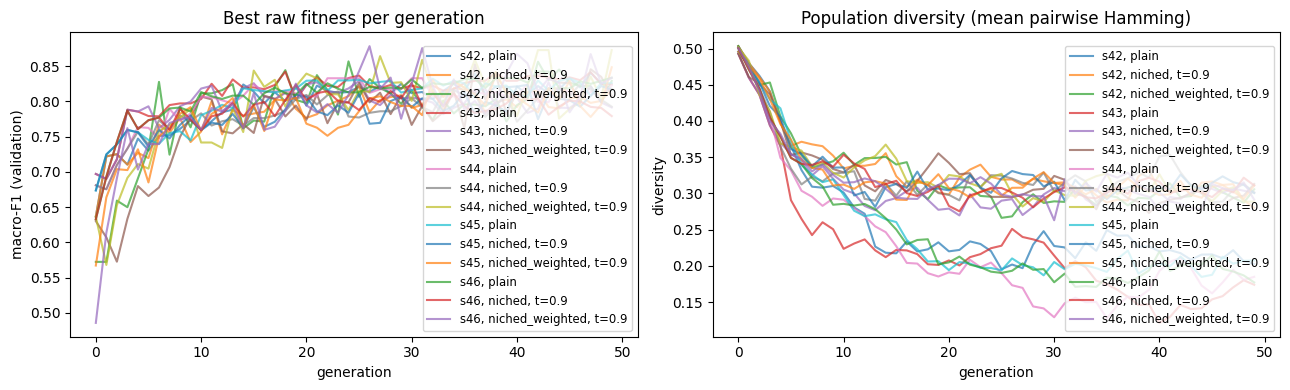

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for (seed, thresh, mode), entry in all_histories.items():
    h = pd.DataFrame(entry["history"])
    label = f"s{seed}, {mode}" + (f", t={thresh}" if thresh is not None else "")
    axes[0].plot(h["generation"], h["best_raw"], label=label, alpha=0.7)
    axes[1].plot(h["generation"], h["diversity"], label=label, alpha=0.7)
axes[0].set_title("Best raw fitness per generation")
axes[0].set_xlabel("generation")
axes[0].set_ylabel("macro-F1 (validation)")
axes[0].legend(fontsize="small", loc="lower right")
axes[1].set_title("Population diversity (mean pairwise Hamming)")
axes[1].set_xlabel("generation")
axes[1].set_ylabel("diversity")
axes[1].legend(fontsize="small", loc="lower right")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "ec_history.png", dpi=150, bbox_inches="tight")
plt.show()

## Stage 5. Summary

In [ ]:
metric_cols = ["accuracy", "macro_f1"] + [c for c in results_df.columns if c.startswith("recall_")]

if len(SEEDS) > 1:
    summary = results_df.groupby("method")[metric_cols].agg(["mean", "std"]).round(3)
    print(f"Summary across {len(SEEDS)} seeds")
else:
    summary = results_df.set_index("method")[metric_cols].round(3)
    print(f"Single seed (seed={SEEDS[0]})")
summary

Summary across 5 seeds


accuracy        macro_f1        recall_22973  \
                                 mean    std     mean    std         mean   
method                                                                      
all_features                    0.826  0.010    0.657  0.043        0.050   
ec_niched_best                  0.810  0.008    0.676  0.030        0.112   
ec_niched_committee             0.828  0.007    0.698  0.032        0.138   
ec_niched_weighted_best         0.836  0.009    0.703  0.032        0.138   
ec_niched_weighted_committee    0.844  0.015    0.711  0.049        0.138   
ec_plain_best                   0.809  0.025    0.705  0.025        0.212   
ec_plain_committee              0.810  0.006    0.691  0.031        0.162   
mrmr_top15                      0.778  0.016    0.599  0.057        0.050   

                                    recall_24279        recall_244024         \
                                std         mean    std          mean    std   
method                                                                         
all_features                  0.112        0.667  0.000         0.638  0.056   
ec_niched_best                0.103        0.667  0.000         0.689  0.072   
ec_niched_committee           0.112        0.667  0.000         0.715  0.032   
ec_niched_weighted_best       0.081        0.667  0.000         0.694  0.044   
ec_niched_weighted_committee  0.128        0.700  0.046         0.685  0.044   
ec_plain_best                 0.056        0.683  0.037         0.660  0.075   
ec_plain_committee            0.122        0.667  0.000         0.677  0.055   
mrmr_top15                    0.112        0.450  0.095         0.660  0.021   

                             recall_banana        recall_rubthr1         
                                      mean    std           mean    std  
method                                                                   
all_features                         0.826  0.038          0.922  0.005  
ec_niched_best                       0.746  0.049          0.911  0.015  
ec_niched_committee                  0.769  0.034          0.926  0.011  
ec_niched_weighted_best              0.802  0.053          0.931  0.008  
ec_niched_weighted_committee         0.835  0.086          0.933  0.007  
ec_plain_best                        0.732  0.033          0.912  0.021  
ec_plain_committee                   0.711  0.021          0.922  0.009  
mrmr_top15                           0.805  0.044          0.856  0.004

In [ ]:
import importlib
from src import evaluate
importlib.reload(evaluate)

<module 'src.evaluate' from 'c:\\Users\\Batoul Hammoud\\Desktop\\naco_project\\src\\evaluate.py'>

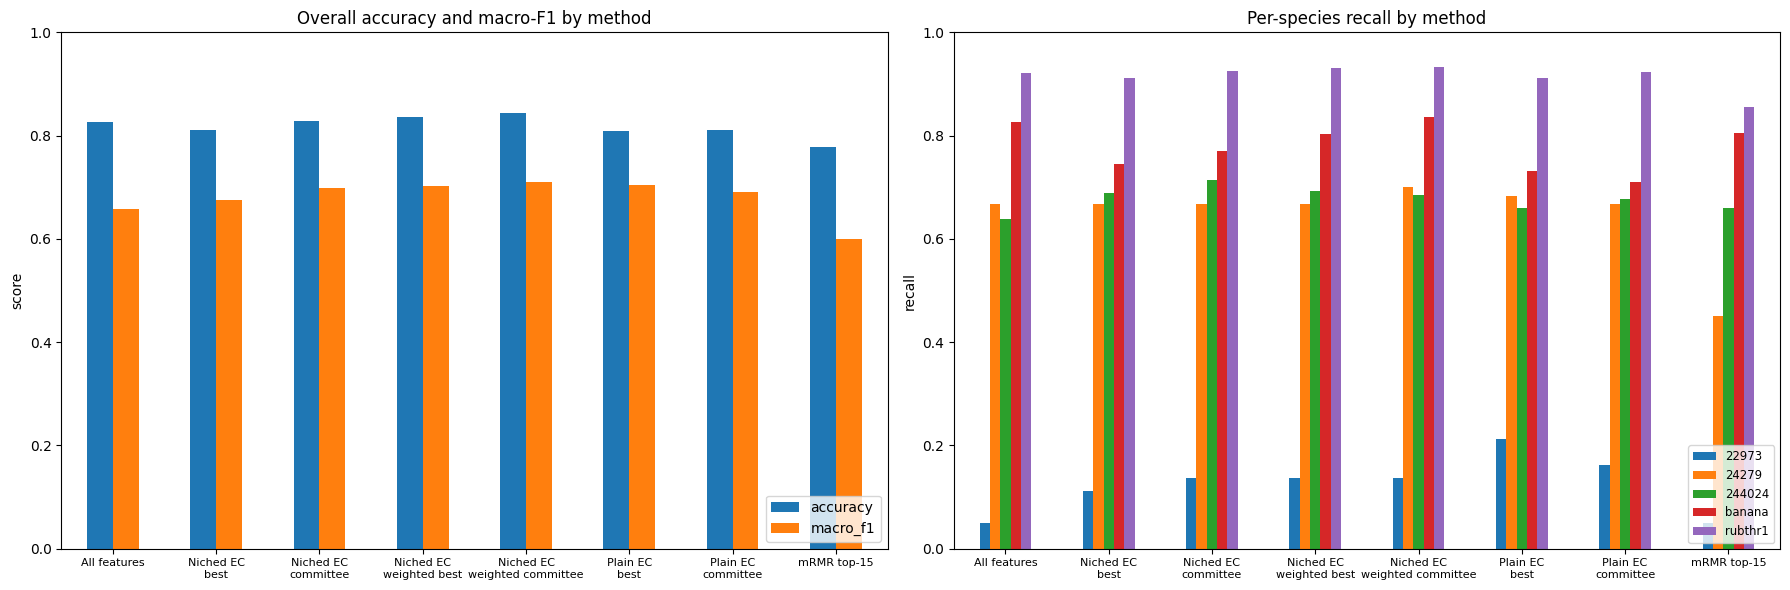

In [ ]:
mean_per_method = results_df.groupby("method")[metric_cols].mean()
fig = evaluate.plot_comparison(
    mean_per_method, save_path=FIGURES_DIR / "comparison.png"
)
plt.show()

## Aggregator

In [21]:
import json
from pathlib import Path

import pandas as pd

runs_root = RESULTS_DIR / "runs"
if not runs_root.exists():
    print("No results/runs/ directory yet.")
else:
    all_dfs = []
    for run_dir in sorted(runs_root.iterdir()):
        if not run_dir.is_dir():
            continue
        comp_path = run_dir / "comparison.csv"
        if not comp_path.exists():
            continue
        df = pd.read_csv(comp_path)
        cfg_path = run_dir / "config.json"
        if cfg_path.exists():
            with open(cfg_path) as f:
                cfg = json.load(f)
            df["run_name"] = cfg.get("run_name", run_dir.name)
            df["env"] = cfg.get("env", "unknown")
            df["seed"] = cfg.get("seed")
            df["threshold"] = cfg.get("sharing_threshold")
        else:
            df["run_name"] = run_dir.name
        all_dfs.append(df)
    if all_dfs:
        all_runs = pd.concat(all_dfs, ignore_index=True)
        cols = ["run_name", "env", "seed", "threshold", "method", "accuracy", "macro_f1"]
        cols += [c for c in all_runs.columns if c.startswith("recall_")]
        cols = [c for c in cols if c in all_runs.columns]
        print(f"Aggregated {len(all_runs)} method-rows from {len(all_dfs)} runs")
        all_runs[cols].round(3)
    else:
        print("No runs in results/runs/ yet.")

Aggregated 5 method-rows from 1 runs
